# BERTopic on 20 Newsgroups (unsupervised)

Walkthrough for the workshop: load the SetFit/20_newsgroups corpus, fit a standard BERTopic pipeline **without using the labels**, and compare its discovered clusters with the original newsgroup classes in a shared 2D UMAP space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

RANDOM_STATE = 42

/home/andres/Documents/MeToD_workshop/src/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the dataset

Pandas reads JSONL directly from the Hugging Face Hub via the `hf://` URI scheme.

In [2]:
splits = {"train": "train.jsonl", "test": "test.jsonl"}
df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/" + splits["train"],
    lines=True,
)
df.head()

,text,label,label_text
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


In [3]:
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df["label_text"].value_counts()

Rows: 11,314  |  Columns: ['text', 'label', 'label_text']


label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64

## 2. Subsample (for workshop speed)

~11k documents take a few minutes to embed on CPU. We keep a stratified sample so every newsgroup is still represented.

In [4]:
N_PER_CLASS = 200
sample = (
    df.groupby("label_text", group_keys=False)
      .sample(n=N_PER_CLASS, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)
docs = sample["text"].tolist()
true_labels = sample["label_text"].tolist()
len(docs)

4000

## 3. Embed the documents

We use `BAAI/bge-base-en-v1.5` (110M params, 768-d) — a modern base-sized sentence encoder, much stronger than the default `all-MiniLM-L6-v2`. On an 8 GB GPU this runs in ~10–15 s.

If you want to push further on the same GPU, try `BAAI/bge-large-en-v1.5` (335M params, 1024-d) — same API, ~3× slower.

In [5]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

encoder = SentenceTransformer("BAAI/bge-base-en-v1.5", device=device)
embeddings = encoder.encode(docs, show_progress_bar=True, batch_size=128, convert_to_numpy=True)
embeddings.shape

Using device: cuda


Batches: 100%|██████████| 32/32 [00:27<00:00,  1.17it/s]


(4000, 768)

## 4. Fit BERTopic — unsupervised

Standard pipeline: **UMAP → HDBSCAN → c-TF-IDF**, no labels passed.

Hyperparameters tuned for ~4 k documents with ~20 underlying classes (defaults yielded ~36 % outliers — too noisy):

- **UMAP** uses BERTopic's documented defaults: `n_neighbors=15`, `n_components=5`, `min_dist=0`, `metric="cosine"`.
- **HDBSCAN** bumps `min_cluster_size` from 10 → 30 (fewer micro-clusters) and sets `min_samples=10 < min_cluster_size` to reduce outliers — the standard noise-reduction trick from the BERTopic FAQ.

In [6]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True,
    calculate_probabilities=False,
)
topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
topic_model.get_topic_info().head(15)

2026-05-16 16:40:25,541 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 16:40:45,778 - BERTopic - Dimensionality - Completed ✓
2026-05-16 16:40:45,779 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 16:40:45,829 - BERTopic - Cluster - Completed ✓
2026-05-16 16:40:45,832 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 16:40:46,123 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,414,-1_maxaxaxaxaxaxaxaxaxaxaxaxaxaxax_the_of_to,"[maxaxaxaxaxaxaxaxaxaxaxaxaxaxax, the, of, to,...",[Try the firearms archive. Larry Cipriani's i...
1,0,1276,0_the_to_for_and,"[the, to, for, and, is, it, of, in, with, you]",[A very kind soul has mailed me this reply for...
2,1,349,1_the_to_and_it,"[the, to, and, it, of, in, is, for, on, car]","[Howdy,\n\nI'm a little new to this newsgroup,..."
3,2,331,2_the_of_that_is,"[the, of, that, is, to, and, in, not, god, it]",[I posted this several days ago for Dave Butle...
4,3,183,3_the_hockey_in_to,"[the, hockey, in, to, he, and, team, of, game,...",[By Dave Luecking Of The Post-Dispatch Staff\n...
5,4,178,4_the_to_of_and,"[the, to, of, and, is, in, be, that, this, file]",[This document is in the anonymous ftp directo...
6,5,167,5_space_the_and_of,"[space, the, and, of, to, for, in, launch, on,...",[Two developments have brought these type of a...
7,6,159,6_the_he_and_to,"[the, he, and, to, in, cubs, year, of, is, was]",[\nI agree and disagree. John is saying that ...
8,7,158,7_of_the_and_to,"[of, the, and, to, is, in, that, it, cancer, for]",[------------- cut here -----------------\nUni...
9,8,157,8_you_to_this_and,"[you, to, this, and, the, that, of, it, have, ...","[\nStill mastering the language, eh? Notice t..."


## 4b. Baseline — vanilla BERTopic

For a fair three-way comparison we also run BERTopic with **all defaults** — no LLM encoder swap, no UMAP/HDBSCAN tuning. The constructor picks `all-MiniLM-L6-v2` (22 M params, 384-d) under the hood and uses `min_cluster_size=10`.

In [7]:
default_model = BERTopic(verbose=True, calculate_probabilities=False)
default_topics, _ = default_model.fit_transform(docs)
default_model.get_topic_info().head(10)

2026-05-16 16:40:46,340 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 125/125 [00:03<00:00, 36.24it/s]
2026-05-16 16:40:55,219 - BERTopic - Embedding - Completed ✓
2026-05-16 16:40:55,219 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 16:41:05,762 - BERTopic - Dimensionality - Completed ✓
2026-05-16 16:41:05,762 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 16:41:05,819 - BERTopic - Cluster - Completed ✓
2026-05-16 16:41:05,821 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 16:41:06,123 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1360,-1_the_to_of_and,"[the, to, of, and, is, in, that, it, for, you]",[\nIf I have a habit that I really want to bre...
1,0,344,0_he_the_team_game,"[he, the, team, game, hockey, in, season, and,...",[\nI am trying to think how to respond to this...
2,1,165,1_for_dos_shipping_sale,"[for, dos, shipping, sale, offer, excellent, d...",[Items for sale.....\n\nThis package was bough...
3,2,163,2_window_the_is_to,"[window, the, is, to, motif, server, can, in, ...",[Archive-name: x-faq/part2\nLast-modified: 199...
4,3,128,3_israel_israeli_of_the,"[israel, israeli, of, the, in, arab, to, that,...",[From: Center for Policy Research <cpr>\nSubje...
5,4,125,4_hi_huh_hello_why,"[hi, huh, hello, why, was, of, , , , ]","[\nHuh?, Hi,, Hi,]"
6,5,118,5_key_encryption_chip_keys,"[key, encryption, chip, keys, the, to, clipper...","[Here is a disturbing thought.\n\nNow, we no l..."
7,6,112,6_file_the_myers_ms,"[file, the, myers, ms, of, gun, by, that, to, ...",[THE WHITE HOUSE\n\n Office...
8,7,82,7_drive_disk_drives_controller,"[drive, disk, drives, controller, bios, hard, ...",[Just wanted to ask a question. I bought a har...
9,8,79,8_windows_dos_file_files,"[windows, dos, file, files, microsoft, os2, to...","[hi,\n Have you used Mac system 6.x or 7.x? I..."


## 5. Three-way comparison in a shared 2D UMAP

We project every document into a single 2D UMAP fit on the **bge-base** embeddings, then overlay three colourings of the *same* points:

- **a** — the human-assigned newsgroup (ground truth).
- **b** — clusters found by vanilla BERTopic (internal MiniLM encoder + default UMAP/HDBSCAN).
- **c** — clusters found after replacing the encoder with **bge-base-en-v1.5** and tuning HDBSCAN (`min_cluster_size=30`, `min_samples=10`).

A clean topic model should reproduce the colour structure of panel **a** — coherent, contiguous, low-outlier regions.

### How to read the comparison

All three panels show the **same 4 000 documents in the same 2D UMAP** — only the colouring changes.

- **Panel a — ground truth.** Documents from each newsgroup should ideally land in a coherent, contiguous region. They mostly do — confirming the bge-base embedding space already separates the 20 newsgroups well.
- **Panel b — vanilla BERTopic.** Same documents, coloured by the clusters found by an off-the-shelf BERTopic call (`BERTopic().fit_transform(docs)`). The MiniLM encoder is weaker and `min_cluster_size=10` lets HDBSCAN split each newsgroup into many small fragments; the high grey area shows the resulting outlier rate.
- **Panel c — tuned BERTopic.** Replacing MiniLM with bge-base sharpens the embedding space; raising `min_cluster_size` to 30 and lowering `min_samples` to 10 collapses fragments into newsgroup-sized topics and pulls many former outliers into clusters.

The visual story is the workshop's main point: a topic model is only as good as **(i)** the embedding space it operates in and **(ii)** the cluster sizes it's allowed to find.

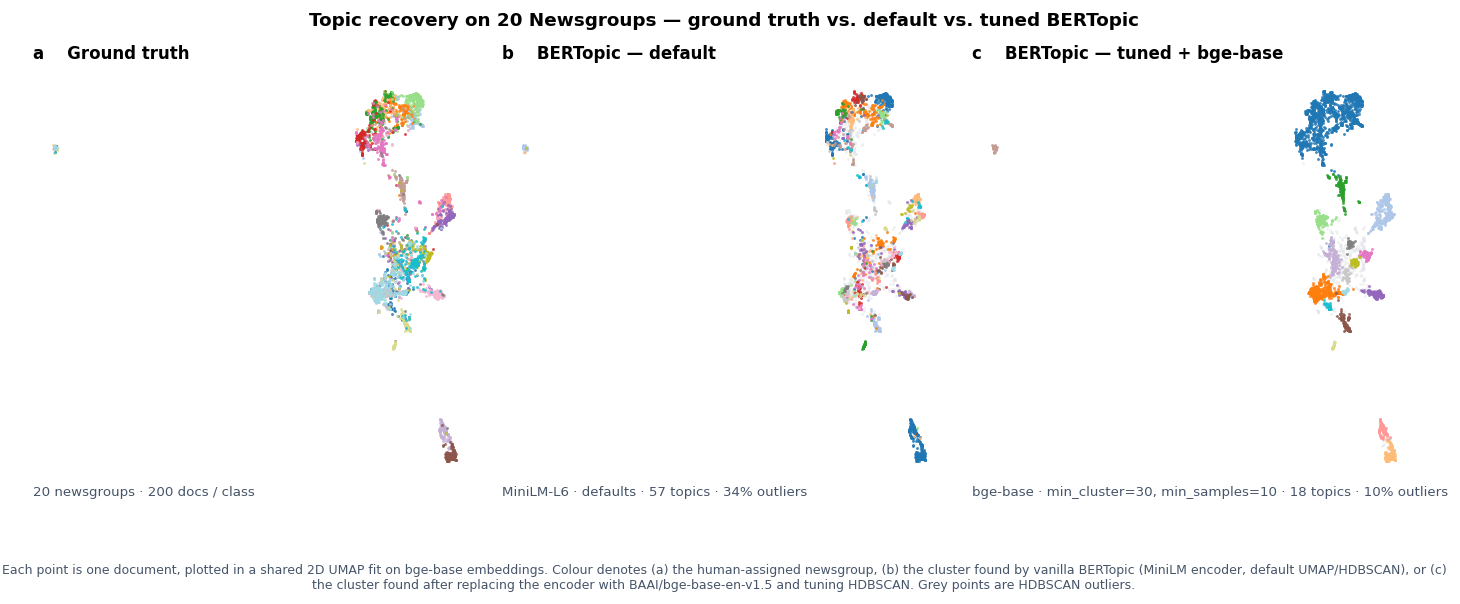

In [8]:
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec

# Publication-style typography (Nature-leaning)
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "savefig.dpi": 300,
    "figure.dpi": 120,
})

# Ensure the 2D UMAP layout is available (re-compute if previous cell was skipped).
if "coords" not in globals():
    coords = UMAP(
        n_components=2, n_neighbors=15, min_dist=0.0,
        metric="cosine", random_state=RANDOM_STATE,
    ).fit_transform(embeddings)

true_arr     = np.array(true_labels)
pred_default = np.array(default_topics)
pred_tuned   = np.array(topics)


def panel_stats(arr):
    ids = np.unique(arr)
    n_topics = int(sum(1 for t in ids if t != -1))
    outliers_pct = float((arr == -1).mean() * 100) if (arr == -1).any() else 0.0
    return n_topics, outliers_pct


def draw(ax, coords, labels, palette="tab20", outlier_color="#e5e7eb"):
    is_int_labels = labels.dtype.kind in ("i", "u")
    if is_int_labels:
        mask_out = labels == -1
        if mask_out.any():
            ax.scatter(coords[mask_out, 0], coords[mask_out, 1],
                       s=3, c=outlier_color, alpha=0.55,
                       linewidths=0, rasterized=True)
        classes = sorted(c for c in np.unique(labels).tolist() if c != -1)
    else:
        classes = sorted(np.unique(labels).tolist())
    cmap = plt.colormaps.get_cmap(palette).resampled(max(len(classes), 1))
    for i, c in enumerate(classes):
        mask = labels == c
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=3, color=cmap(i % cmap.N), alpha=0.85,
                   linewidths=0, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ("top", "right", "bottom", "left"):
        ax.spines[s].set_visible(False)


n_def, out_def = panel_stats(pred_default)
n_tun, out_tun = panel_stats(pred_tuned)
n_true = len(np.unique(true_arr))

# Manual grid: 3 equal-width panels, leave room for suptitle and caption.
fig = plt.figure(figsize=(12, 5.0))
gs = GridSpec(
    1, 3,
    figure=fig,
    left=0.02, right=0.98,
    top=0.86, bottom=0.18,
    wspace=0.06,
)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Lock data extent identically on all three panels
xpad = 0.05 * (coords[:, 0].max() - coords[:, 0].min())
ypad = 0.05 * (coords[:, 1].max() - coords[:, 1].min())
xlim = (coords[:, 0].min() - xpad, coords[:, 0].max() + xpad)
ylim = (coords[:, 1].min() - ypad, coords[:, 1].max() + ypad)

panels = [
    (axes[0], true_arr,     "a    Ground truth",
     f"{n_true} newsgroups · 200 docs / class"),
    (axes[1], pred_default, "b    BERTopic — default",
     f"MiniLM-L6 · defaults · {n_def} topics · {out_def:.0f}% outliers"),
    (axes[2], pred_tuned,   "c    BERTopic — tuned + bge-base",
     f"bge-base · min_cluster=30, min_samples=10 · {n_tun} topics · {out_tun:.0f}% outliers"),
]
for ax, labels, title, subtitle in panels:
    draw(ax, coords, labels)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(title, loc="left", pad=8)
    ax.text(0.0, -0.04, subtitle, transform=ax.transAxes,
            fontsize=8, color="#475569")

fig.suptitle(
    "Topic recovery on 20 Newsgroups — ground truth vs. default vs. tuned BERTopic",
    fontsize=11, fontweight="bold", y=0.96,
)

fig.text(
    0.5, 0.04,
    "Each point is one document, plotted in a shared 2D UMAP fit on bge-base embeddings. "
    "Colour denotes (a) the human-assigned newsgroup, (b) the cluster found by vanilla BERTopic "
    "(MiniLM encoder, default UMAP/HDBSCAN), or (c) the cluster found after replacing the encoder "
    "with BAAI/bge-base-en-v1.5 and tuning HDBSCAN. Grey points are HDBSCAN outliers.",
    ha="center", va="top", fontsize=7.5, color="#475569", wrap=True,
)

plt.savefig("topic_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### How to read the comparison

Both plots show the **same documents in the same 2D space** — only the colouring differs. On the left, colours are the true newsgroup; on the right, colours are BERTopic's discovered clusters (grey = outliers HDBSCAN couldn't place).

If embeddings carry the topical signal well, regions that are one colour on the left should also be one colour on the right. Where BERTopic merges several newsgroups into one cluster (or splits one newsgroup across many), you can see *what the embedding space actually thinks is similar* — independent of the human-assigned labels.